In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [ ]:
# Load the data sets
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
print("Train shape:", train.shape, " Test shape:", test.shape)

Train shape: (300000, 323)  Test shape: (100000, 322)


In [ ]:
# Using Pre Trained Features
# Drop id and 'tip_over_10pct' columns
TARGET = "tip_over_10pct"

drop_cols = {"id", TARGET}
feature_cols = [c for c in train.columns if c not in drop_cols]

# Train matrices
X = train[feature_cols].copy()
y = train[TARGET].astype(int).copy()

# Test matrices: align exactly to train feature set
X_test = test.reindex(columns=feature_cols, fill_value=0).copy()

# Safety: fill any residual NaNs and downcast
X = X.fillna(0).astype(np.float32)
X_test = X_test.fillna(0).astype(np.float32)

print(f"Features: {len(feature_cols)}")
print("Train X:", X.shape, "| Train y:", y.shape, "| Test X:", X_test.shape)

Features: 321
Train X: (300000, 321) | Train y: (300000,) | Test X: (100000, 321)


In [ ]:
# MODEL SELECTION
# 3-fold CV accuracy for:
#   • Logistic Regression (baseline, sparse-friendly)
#   • Random Forest
#   • Gradient Boosting
models = {
    "logreg_saga": LogisticRegression(
        penalty="l2", C=1.0, solver="saga",
        max_iter=400, n_jobs=1, random_state=42
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_leaf=2,
        n_jobs=1, random_state=42
    ),
    "gbdt": GradientBoostingClassifier(
        learning_rate=0.08, n_estimators=250, max_depth=3,
        random_state=42
    ),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_scores = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[("clf", clf)])
    scores = cross_val_score(
        pipe, X, y, scoring="accuracy", cv=cv,
        n_jobs=1, pre_dispatch="1*n_jobs"
    )
    cv_scores[name] = (scores.mean(), scores.std())
    print(f"{name}: ACC {scores.mean():.4f} ± {scores.std():.4f}")

cv_scores

logreg_saga: ACC 0.7081 ± 0.0616
random_forest: ACC 0.9232 ± 0.0001
gbdt: ACC 0.9225 ± 0.0002


{'logreg_saga': (np.float64(0.7081366666666667),
  np.float64(0.061615291031438715)),
 'random_forest': (np.float64(0.9232266666666668),
  np.float64(5.436502143432447e-05)),
 'gbdt': (np.float64(0.9225433333333334), np.float64(0.0002460803843372388))}

/tmp/ipython-input-2587947988.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipython-input-2587947988.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=12)


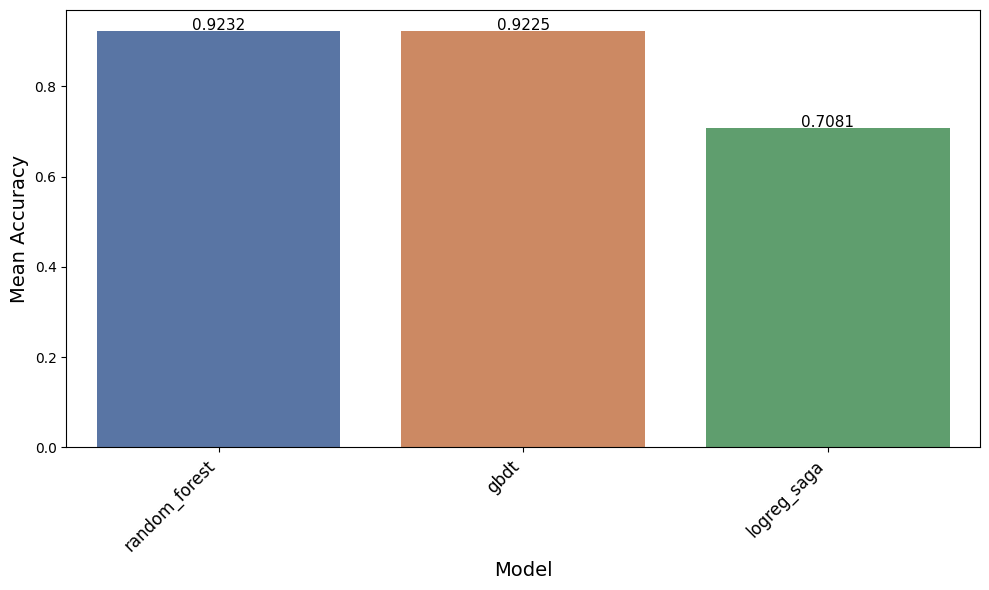

,Model,Mean_Accuracy,Std
1,random_forest,0.923227,0.000054
2,gbdt,0.922543,0.000246
0,logreg_saga,0.708137,0.061615


In [ ]:
# VISUALIZE CROSS-VALIDATION ACCURACY
# CV scores dictionary to DataFrame
cv_df = pd.DataFrame([
    {"Model": k, "Mean_Accuracy": v[0], "Std": v[1]}
    for k, v in cv_scores.items()
]).sort_values("Mean_Accuracy", ascending=False)

# Bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x="Model", y="Mean_Accuracy",
    data=cv_df, palette="deep"
)

# Labels & formatting
ax.set_xlabel("Model", fontsize=14)
ax.set_ylabel("Mean Accuracy", fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=12)

# Annotate bars with accuracy values
for i, row in enumerate(cv_df.itertuples(), 0):
    ax.text(
        i, row.Mean_Accuracy + 0.002,
        f"{row.Mean_Accuracy:.4f}",
        ha="center", fontsize=11, color="black"
    )

plt.tight_layout()
plt.show()

cv_df

In [ ]:
# FINAL TRAINING & PREDICTION
# Picks best model
# Trains on train.csv
# Predicts tip_over_10pct for test.csv
# Saves submission.csv (id, tip_over_10pct)

# Pick best by CV mean accuracy
best_name = max(cv_scores, key=lambda k: cv_scores[k][0])
print("Best by CV:", best_name, cv_scores[best_name])

# Rebuild the winning estimator with same hyperparams
if best_name == "logreg_saga":
    best_model = LogisticRegression(
        penalty="l2", C=1.0, solver="saga",
        max_iter=400, n_jobs=1, random_state=42,
        class_weight="balanced"
    )
elif best_name == "random_forest":
    best_model = RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_leaf=2,
        n_jobs=1, random_state=42
    )
else:
    best_model = GradientBoostingClassifier(
        learning_rate=0.08, n_estimators=250, max_depth=3,
        random_state=42
    )

# Train on train.csv
best_model.fit(X, y)

# Predict on test.csv
test_pred = best_model.predict(X_test).astype(int)

# Build submission and save
if "id" in test.columns:
    submission = pd.DataFrame({"id": test["id"], "tip_over_10pct": test_pred})
else:
    submission = pd.DataFrame({"id": np.arange(len(test_pred)), "tip_over_10pct": test_pred})

submission.to_csv("submission.csv", index=False)
submission.head()

Best by CV: random_forest (np.float64(0.9232266666666668), np.float64(5.436502143432447e-05))


,id,tip_over_10pct
0,te_0,1
1,te_1,1
2,te_2,1
3,te_3,0
4,te_4,1


/tmp/ipython-input-3744801463.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Class", y="Count", data=pred_counts, palette="deep")
/tmp/ipython-input-3744801463.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["0 (Tip ≤ 10%)", "1 (Tip > 10%)"], fontsize=12)


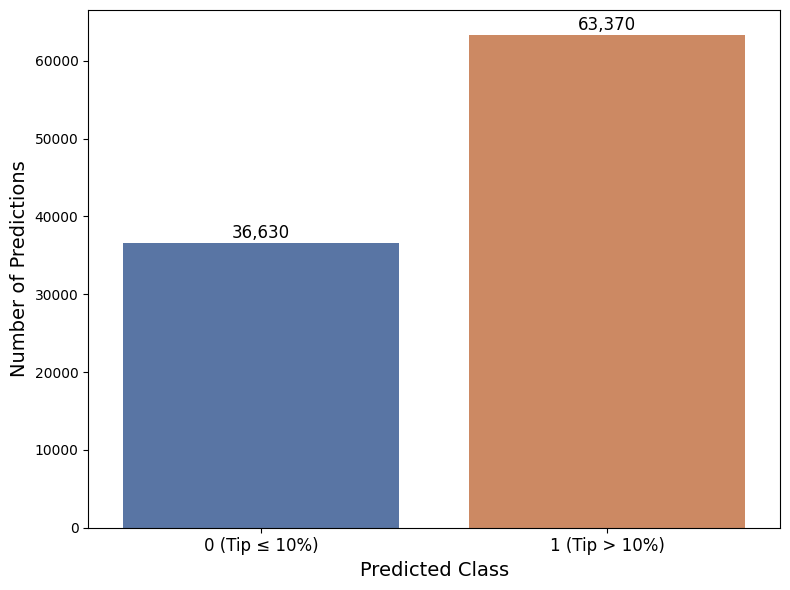

,Class,Count
1,0,36630
0,1,63370


In [ ]:
# VISUALIZE PREDICTION DISTRIBUTION
# DataFrame for visualization
pred_df = pd.DataFrame({"Prediction": test_pred})
pred_counts = pred_df["Prediction"].value_counts().reset_index()
pred_counts.columns = ["Class", "Count"]
pred_counts = pred_counts.sort_values("Class")

# Bar chart
plt.figure(figsize=(8, 6))
ax = sns.barplot(x="Class", y="Count", data=pred_counts, palette="deep")

# Labels & formatting
ax.set_xlabel("Predicted Class", fontsize=14)
ax.set_ylabel("Number of Predictions", fontsize=14)
ax.set_xticklabels(["0 (Tip ≤ 10%)", "1 (Tip > 10%)"], fontsize=12)

# Annotate bars with counts
for i, row in enumerate(pred_counts.itertuples(), 0):
    ax.text(
        i, row.Count + (0.01 * pred_counts["Count"].max()),  # small offset
        f"{row.Count:,}", ha="center", fontsize=12, color="black"
    )

plt.tight_layout()
plt.show()

pred_counts